_______
_______


# <center>Chapter 6: Coordinates, Vectors, and Modeling a Curve<br><sup><sup><br>The Python code was developed based on the R code written by <br> Samuel Shen, Distinguished Professor, San Diego State University, California, USA 
_______
_______

In [1]:
##### For first time Python users, these packages must be installed first
import numpy as np
import math
import pandas as pd
import statistics as stats
import scipy.stats as scistats
from scipy.stats import norm
import matplotlib.pyplot as plt
import random

In [28]:
#Use same plot style as book for consistency
styledict = {'xtick.labelsize':12,
             'xtick.major.size':9,
             'xtick.major.width':1,
             'ytick.labelsize':12,
             'ytick.major.size':9,
             'ytick.major.width':1,
             'legend.framealpha':0.0,
             'legend.fontsize':15,
             'axes.labelsize':12,
             'axes.titlesize':14,
             'axes.titleweight': 'bold',
             'axes.linewidth':1,
             'figure.figsize':(6,6),
             'savefig.format':'jpg'}
plt.rcParams.update(**styledict)

### Plotting points on a graph

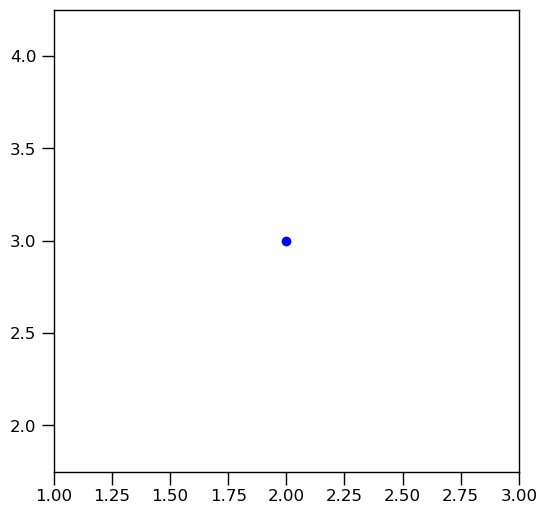

In [3]:
#Plotting the point (2,3)
x = 2
y = 3

#Plotting circular point
#Can also define color and marker style with 'bo'
plt.plot(x, y, color='blue', marker='o')
plt.xlim(1,3) #Adjust limits of axes
plt.ylim(1.75,4.25)
plt.show()

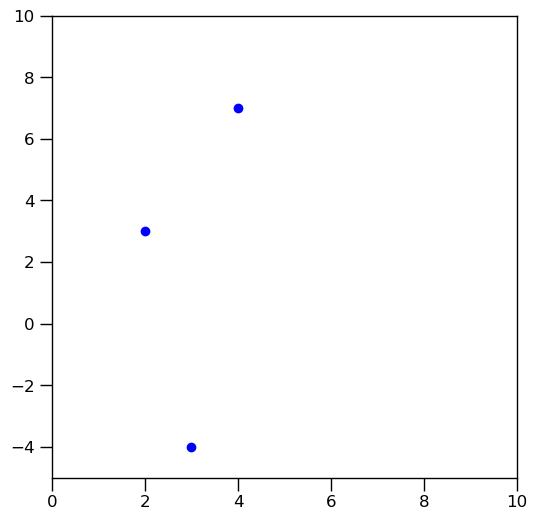

In [4]:
#Plotting several points
#Define x values
x = [2, 4, 3]
y = [3, 7, -4]

plt.plot(x, y, 'bo')
plt.xlim(0,10)
plt.ylim(-5, 10)
plt.show()

### Fig 6.2: Point moves on a circle

In [5]:
R = 3 #Radius
n = 41 #Number of points
omg = 2 #Omega

#Our range from 0-3 with 41 points
t = np.linspace(0, 3, n)

In [6]:
#Define our (x,y) coordinates of our circle
#Returns Rcos(omega*t) for all elements in t array
x = R*np.cos(omg*t)
#Same operation for sin
y = R*np.sin(omg*t)

#Define theta
theta = np.linspace(0, 3/10, n)

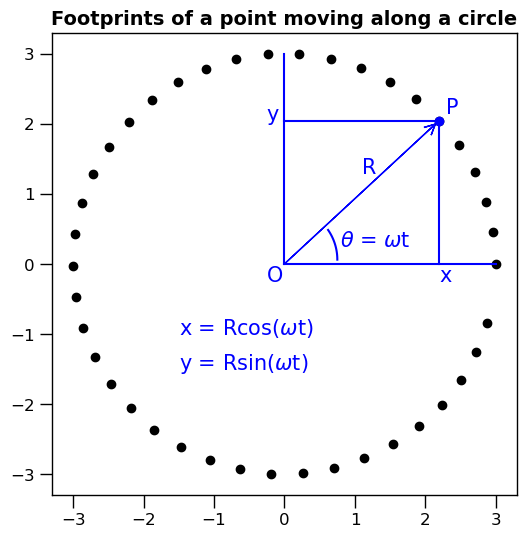

In [7]:
#Plot points
plt.plot(x, y, 'ko')

#Add blue arrow with angle theta
plt.arrow(0, 0, x[5]*0.925, y[5]*0.925, head_width = 0.15, 
          head_length = 0.15, color='blue', overhang=1)

#Plot visualization of angle theta
x_angle = 0.25*R*np.cos(omg*theta)
y_angle = 0.25*R*np.sin(omg*theta)
plt.plot(x_angle, y_angle+0.06, 'b') #Centered

#Plot the horizontal and vertical lines
#Vertical line up from the origin
plt.plot([0, 0], [x[0], y[0]], 'b')
#Horizontal line to the right from the origin
plt.plot([x[0], y[0]], [0, 0], 'b')
#Horizontal line from y to point P
plt.plot([0, x[5]], [y[5], y[5]], 'b')
#Vertical line from x to point P
plt.plot([x[5], x[5]], [0, y[5]], 'b') 
#Highlight our point by plotting another blue point on top
plt.plot(x[5], y[5], 'bo') 

#Add text
plt.text(x[5], -0.25, 'x', color='blue', fontsize=15)
plt.text(-0.25, y[5], 'y', color='blue', fontsize=15)
plt.text(x[5]+0.1, y[5]+0.1, 'P', 
         color='blue', fontsize=15)
plt.text(x[5]-1.1, y[5]-0.75, 'R', color='blue', 
         fontsize=15)
plt.text(-0.25, -0.25, 'O', color='blue', fontsize=15)
plt.text(x[5]-1.4, 0.25, r'$\theta$ = $\omega$t', 
         color='blue', fontsize=15)
plt.text(-1.5, -1, r'x = Rcos($\omega$t)', color='blue', 
         fontsize=15)
plt.text(-1.5, -1.5, r'y = Rsin($\omega$t)', color='blue', 
         fontsize=15)

plt.title('Footprints of a point moving along a circle')

plt.show()

### Directions of a moving point on a circle

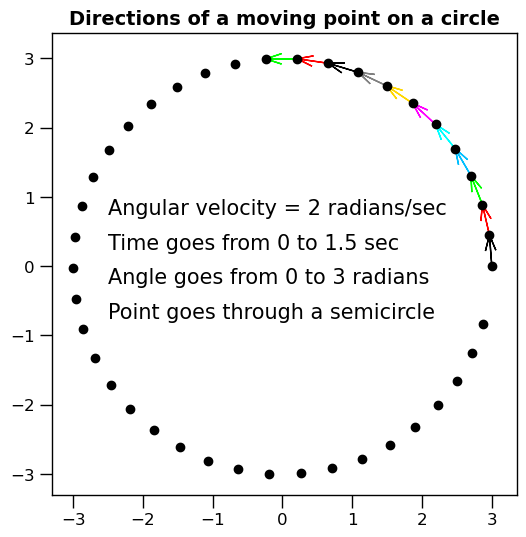

In [8]:
#We would like to plot the directional arrows of the first 11 points
s = np.arange(11)
#List of colors
colors = ['black', 'red', 'lime', 'deepskyblue', 'cyan', 'magenta', 
          'gold', 'grey']

#Plot points
plt.plot(x, y, 'ko')
#Use loop to plot arrows from one point to the next
for i in range(11):
    #Repeat colors using modulo function 
    plt.arrow(x[i], y[i], (x[i+1]-x[i])*.5, (y[i+1]-y[i])*.5, 
              head_width=0.15, color=colors[i%8], overhang=1)
plt.text(-2.5, 0.75, 'Angular velocity = 2 radians/sec', 
         fontsize=15)
plt.text(-2.5, 0.25, 'Time goes from 0 to 1.5 sec', 
         fontsize=15)
plt.text(-2.5, -0.25, 'Angle goes from 0 to 3 radians', 
         fontsize=15)
plt.text(-2.5, -0.75, 'Point goes through a semicircle', 
         fontsize=15)
plt.title('Directions of a moving point on a circle')
plt.show()

### Fig 6.3: A Point is Spiraling Out

In [9]:
n = 81
omg = 2
t = np.linspace(0, 12, n)

x = 2*t*np.cos(omg*t)
y = 2*t*np.sin(omg*t)

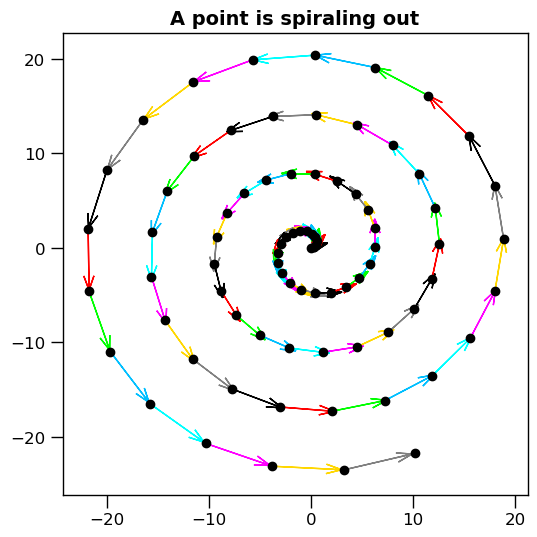

In [10]:
#Plot
plt.plot(x, y, 'ko')
for i in range(n-1):
    plt.arrow(x[i], y[i], (x[i+1]-x[i])*.75, (y[i+1]-y[i])*.75, 
              head_width=1, color=colors[i%8], overhang=1)
    
plt.title('A point is spiraling out')
plt.show()

### 6.4: Heart-shape Path of a Point

In [11]:
n = 41
omg = 2
t = np.linspace(0, 2*np.pi - 0.15, n)

x = 2*np.sin(omg*t) + 5*np.sin(omg*t/2)
y = 2*np.cos(omg*t) + 5*np.cos(omg*t/2)

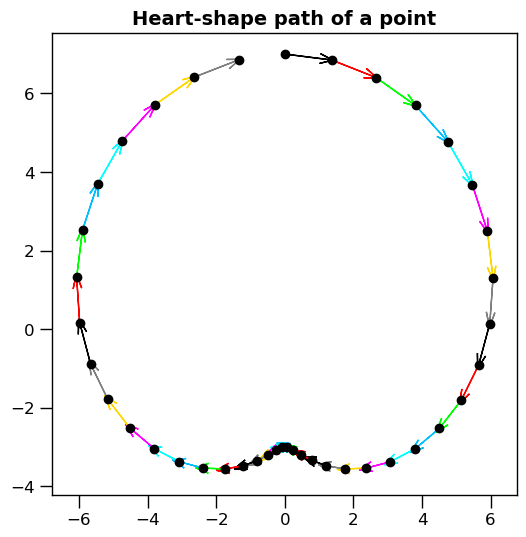

In [12]:
plt.plot(x, y, 'ko')
for i in range(n-1):
    plt.arrow(x[i], y[i], (x[i+1]-x[i])*.75, (y[i+1]-y[i])*.75, 
              head_width=0.25, color=colors[i%8], overhang=1)
    
plt.title('Heart-shape path of a point')
plt.show()

### Fig 6.5: Model Flower Pedals

In [13]:
a = 3
n = 1000
omg = 2
t = np.linspace(0, 2*np.pi, n)
theta = omg*t
r = a*np.cos(4*theta)
x = r*np.cos(theta)
y = r*np.sin(theta)

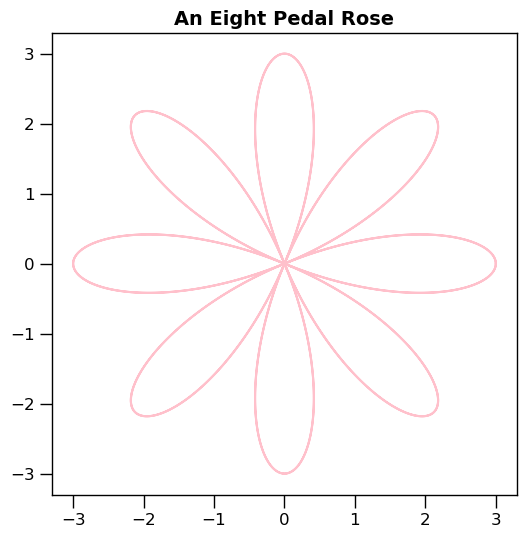

In [14]:
plt.plot(x, y, 'pink')
plt.title('An Eight Pedal Rose')
plt.show()

### Infinitely many petals

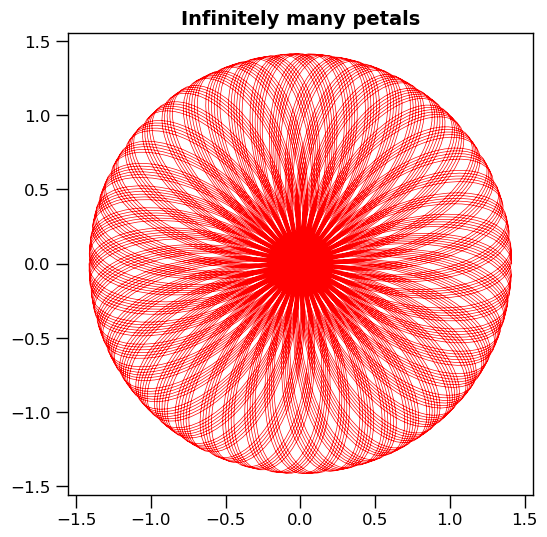

In [15]:
#Redefine t and corresponding functions
n = 10000
t = np.linspace(0, 40*np.pi, n)
omg = 2
theta = omg*t
a = math.sqrt(2)
r = a*np.cos(np.pi*theta)
x = r*np.cos(theta)
y = r*np.sin(theta)

#Plot function
plt.plot(x, y, 'red', linewidth = 0.5)
plt.title('Infinitely many petals')
plt.show()

### Fig 6.7: Vector OP

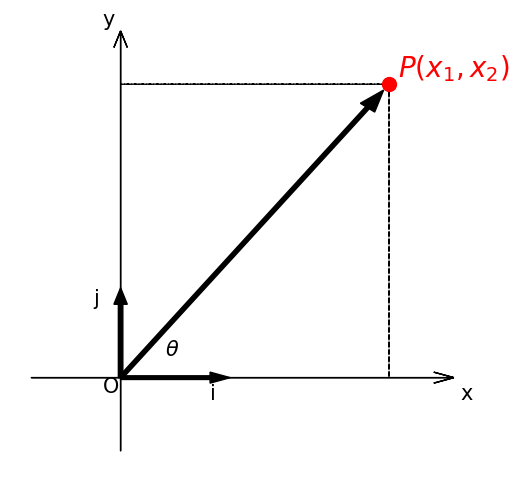

In [16]:
#Plot diagram of a vector to a point P(x1, x2)
plt.plot(3, 4, 'ro' , markersize = 10)
plt.arrow(0, 0, 3*0.92, 4*0.92, width = 0.05, 
          head_width = 0.2, 
          color = 'black')
plt.arrow(-1, 0, 4.5, 0, head_width = 0.15, 
          color = 'black', overhang = 1)
plt.arrow(0, -1, 0, 5.5, head_width = 0.15, 
          color = 'black', overhang = 1)
plt.arrow(0, 0, 0, 1, width = 0.05, color = 'black')
plt.arrow(0, 0, 1, 0, width = 0.05, color = 'black')
plt.arrow(3, 0, 0, 4, linestyle = 'dashed')
plt.arrow(0, 4, 3, 0, linestyle = 'dashed')
plt.text(3.1, 4.1, r'$P(x_1, x_2)$', color = 'red', 
         fontsize = 20)
plt.text(0.5, 0.3, r'$\theta$', fontsize = 15)
plt.text(-0.2, -0.2, 'O', fontsize = 15)
plt.text(1, -0.3, 'i', fontsize = 15)
plt.text(-0.3, 1, 'j', fontsize = 15)
plt.text(3.8, -0.3, 'x', fontsize = 15)
plt.text(-0.2, 4.8, 'y', fontsize = 15)
plt.axis('off')
plt.show()

### Python commands for entering data

In [17]:
#Built in lists
#Square brackets contain data, seperated by commas
x = [1.4, -2.6, 0.9, -3.7, 4.1, 3.2, 5.0]
x

[1.4, -2.6, 0.9, -3.7, 4.1, 3.2, 5.0]

In [18]:
#Can also use numpy arrays with same notation
x = np.array([1.4, -2.6, 0.9, -3.7, 4.1, 3.2, 5.0])
x

array([ 1.4, -2.6,  0.9, -3.7,  4.1,  3.2,  5. ])

### Python commands for vector addition and subtraction

In [19]:
#Built in lists do not perform element-wise operations
u = [3, 4]
v = [-2.5, 1.5]
#Will add elements of v to the end of u
x = u + v
x

[3, 4, -2.5, 1.5]

In [20]:
#Cannot use '-' operator on lists for this reason
#y = x - v #Returns error

In [21]:
#Numpy arrays allow for element-wise operations
u = np.array([3, 4])
v = np.array([-2.5, 1.5])
x = u + v
y = u - v
x

array([0.5, 5.5])

In [22]:
y

array([5.5, 2.5])

### Fig 6.8: Addition and subtraction of two vectors

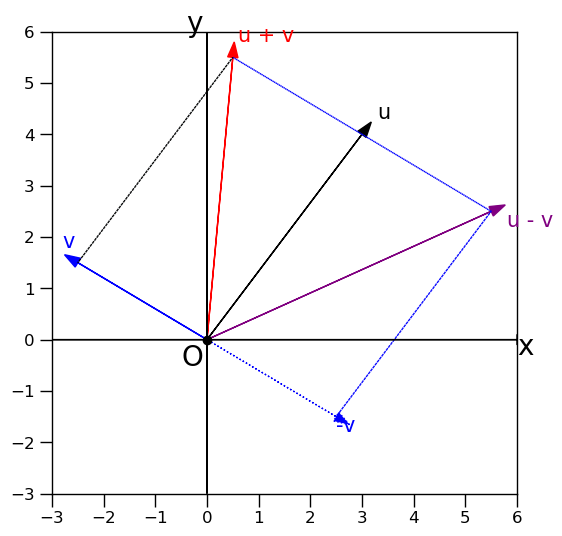

In [23]:
#Using the same vectors from abve
plt.plot(0,0, color = 'black', marker = 'o')
plt.axis([-3, 6, -3, 6])

plt.arrow(0, 0, u[0], u[1], head_width = 0.2, color = 'black')
plt.arrow(0, 0, v[0], v[1], head_width = 0.2, color = 'blue')
plt.arrow(0, 0, -v[0], -v[1], color = 'blue', head_width = 0.2, linestyle = 'dotted')
plt.arrow(0, 0, x[0], x[1], head_width = 0.2, color = 'red')
plt.arrow(0, 0, y[0], y[1], head_width = 0.2, color = 'purple')
plt.arrow(x[0], x[1], u[0]-x[0], u[1]-x[1], linestyle = "dotted", color = 'blue')
plt.arrow(x[0], x[1], v[0]-x[0], v[1]-x[1], linestyle = "dotted")
plt.arrow(u[0], u[1], y[0]-u[0], y[1]-u[1], linestyle ="dotted", color = 'blue')
plt.arrow(y[0], y[1], -v[0]-y[0], -v[1]-y[1], linestyle ="dotted", color = 'blue')

plt.arrow(-3, 0, 9, 0, head_width = 0.2 )
plt.arrow(0, -3, 0, 9, head_width = 0.2 )
plt.text(u[0] + 0.3, u[1] + 0.3, 'u', fontsize = 15)
plt.text(v[0] - 0.3, v[1] + 0.3, 'v', color = 'blue', fontsize = 15)
plt.text(-v[0], -v[1] - 0.3, '-v', color = 'blue', fontsize = 15)
plt.text(x[0] + 0.1, x[1] + 0.3, 'u + v', color = 'red', fontsize = 15)
plt.text(y[0] + 0.3, y[1] - 0.3, 'u - v', color = 'purple', fontsize = 15)

plt.text(-0.5, -0.5, 'O', fontsize = 20)
plt.text(6, -0.3, 'x', fontsize = 20)
plt.text(-0.4, 6,  'y', fontsize = 20)

plt.show()


### R plot Fig. 6.10: Colorado temperature and elevation

In [24]:
#Define arrays of data for elevation and temperature
x = [1671.5, 1635.6, 2097.0, 1295.4, 1822.7, 2396.9, 2763.0, 1284.7,
     1525.2, 1328.6, 1378.9, 2323.8, 2757.8, 1033.3, 1105.5, 1185.7,
     2343.9, 1764.5, 1271.0, 2347.3, 2094.0, 2643.2, 1837.9, 1121.7]
y= [22.064, 23.591, 18.464, 23.995, 20.645, 17.175, 13.582, 24.635,
     22.178, 24.002, 23.952, 16.613, 13.588, 25.645, 25.625, 25.828,
     17.626, 22.433, 24.539, 17.364, 17.327, 15.413, 22.174, 24.549]

In [26]:
#Find the correlation coeffiecient between two arrays
#The correlation coefficient is found on the off-diagonals
np.corrcoef(x, y)

array([[ 1.        , -0.98138583],
       [-0.98138583,  1.        ]])

In [27]:
#Calculate mean
np.mean(x)

1792.8791666666666